Dataset shape: (2, 4)

First few rows:
           iq  final_score  attempts  passed
0  113.789661          0.6         1       1
1   94.629610          0.7         1       1

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   iq           2 non-null      float64
 1   final_score  2 non-null      float64
 2   attempts     2 non-null      int64  
 3   passed       2 non-null      int64  
dtypes: float64(2), int64(2)
memory usage: 196.0 bytes
None

Class distribution:
passed
1    2
Name: count, dtype: int64

WORKING WITH SYNTHETIC DATASET (500 samples)

Synthetic dataset info:
           iq  final_score  attempts  passed
0  107.450712     0.788927         1       1
1   97.926035     0.936412         1       1
2  109.715328     0.440215         1       1
3  122.845448     0.734445         2       1
4   96.487699     0.552404         1       0

Class d

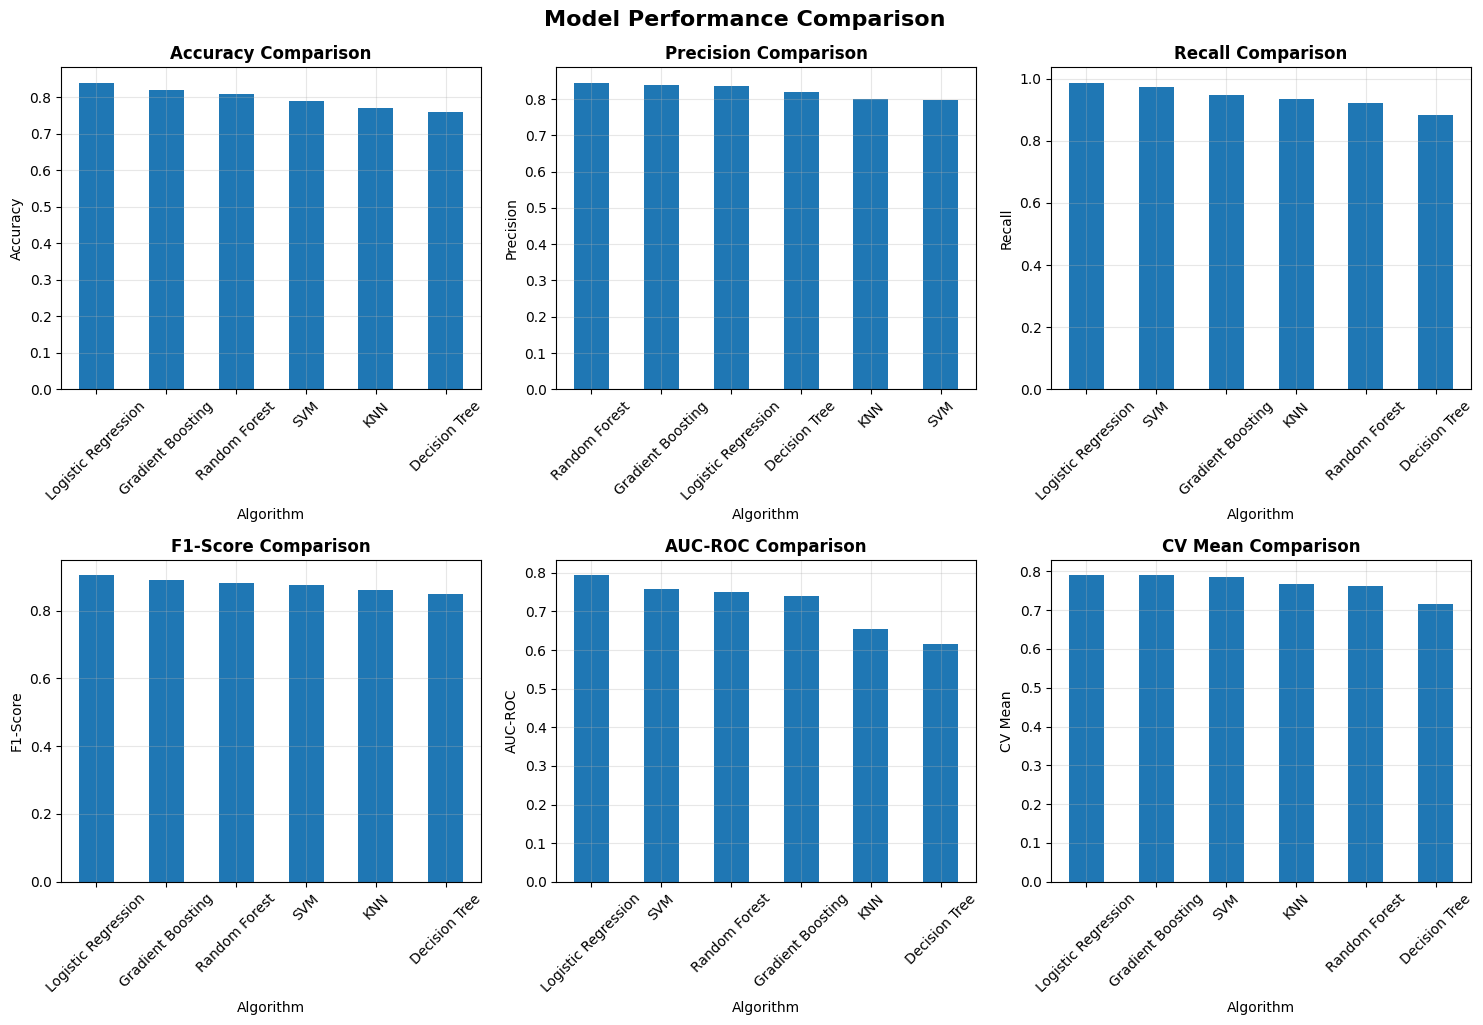

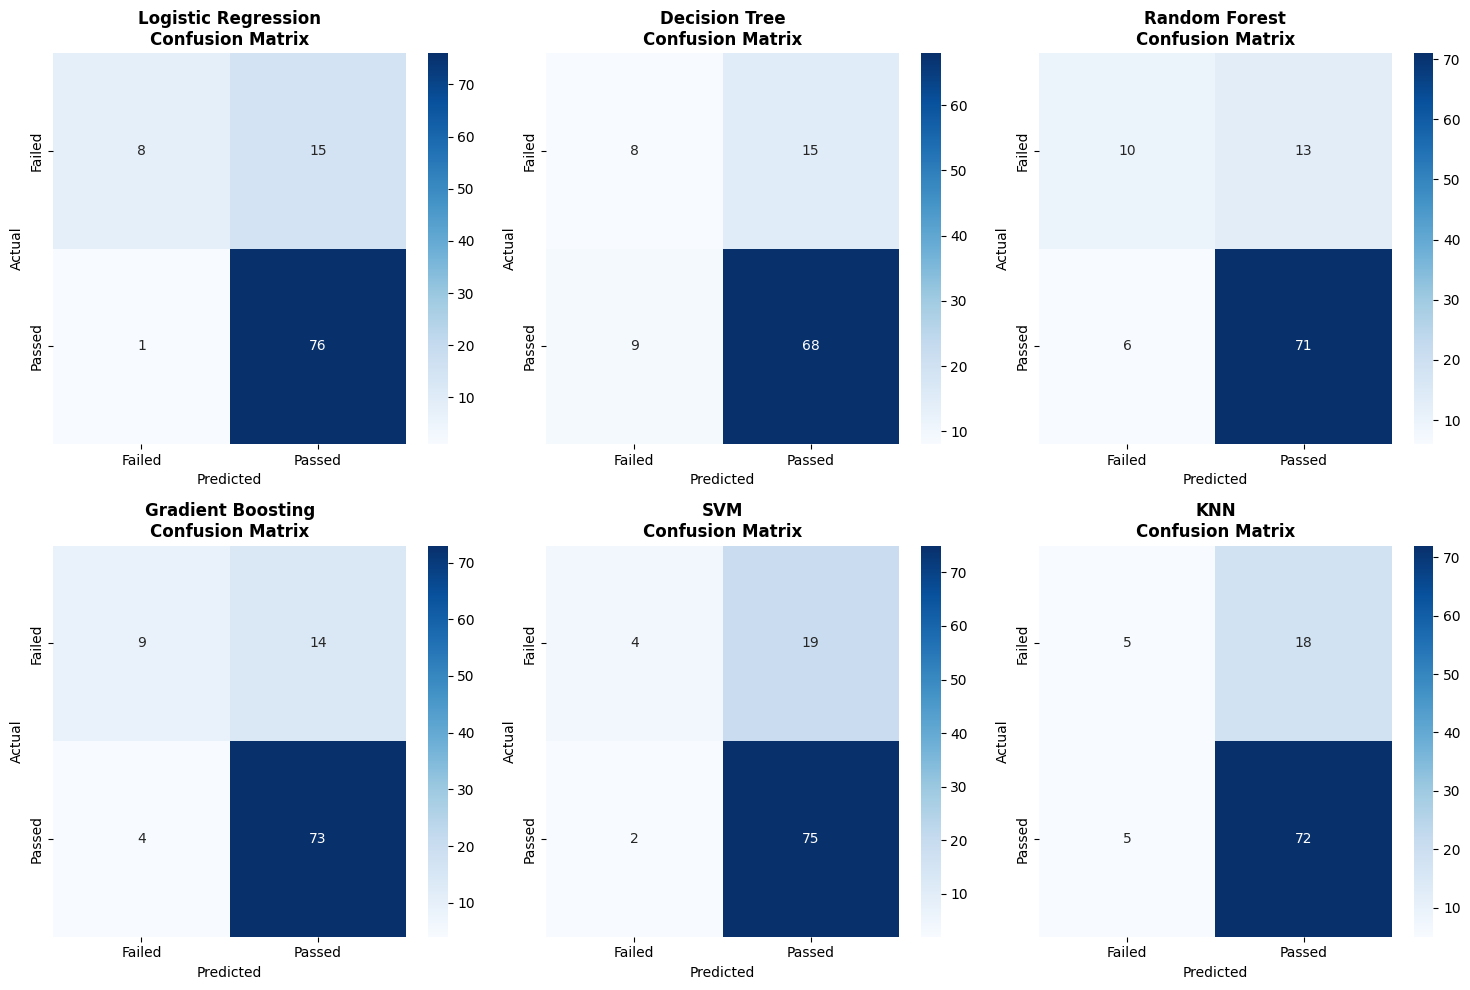

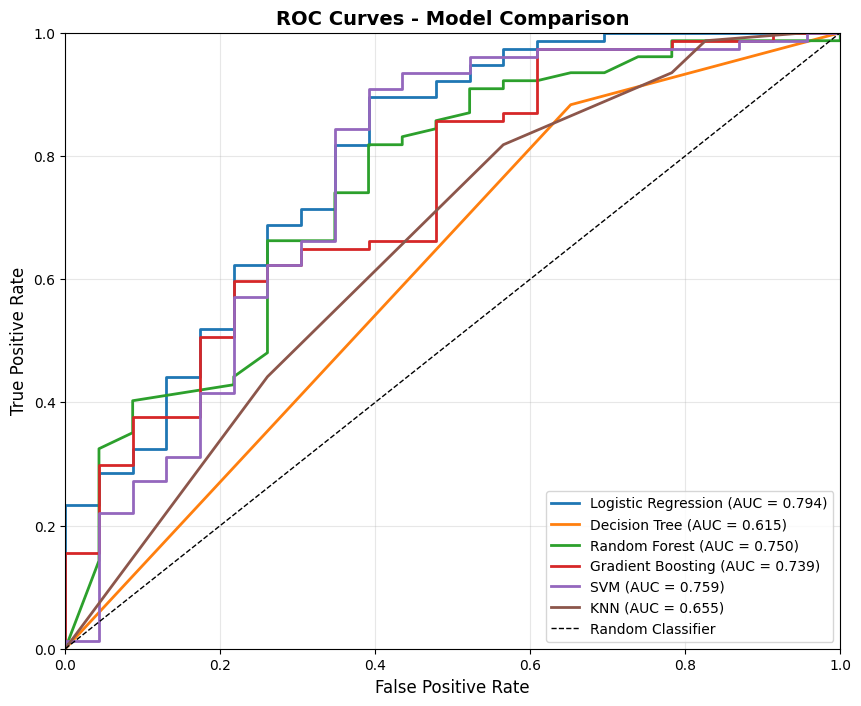

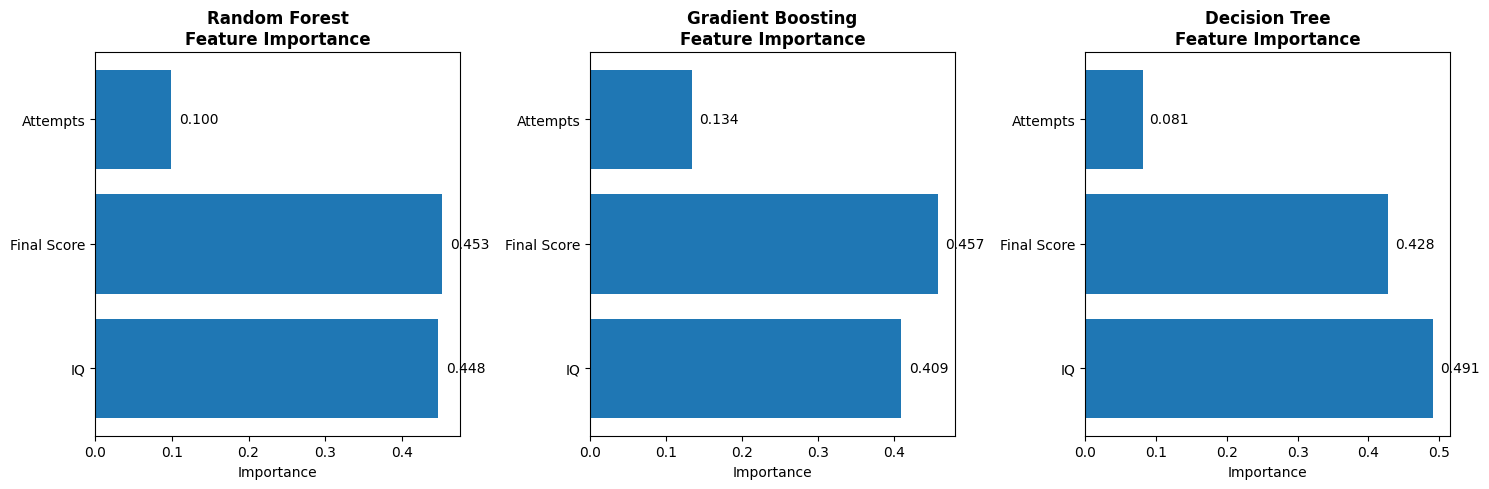

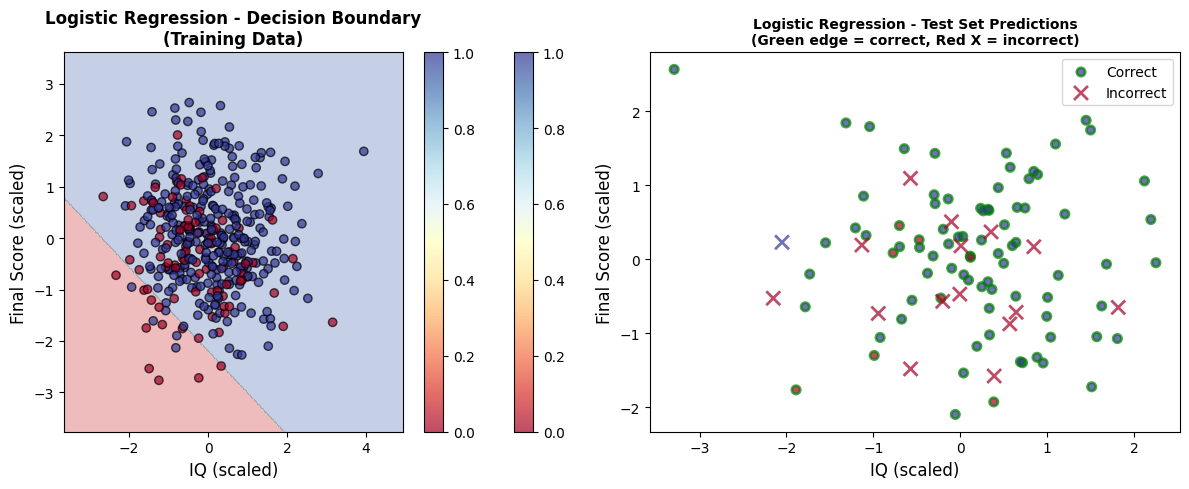

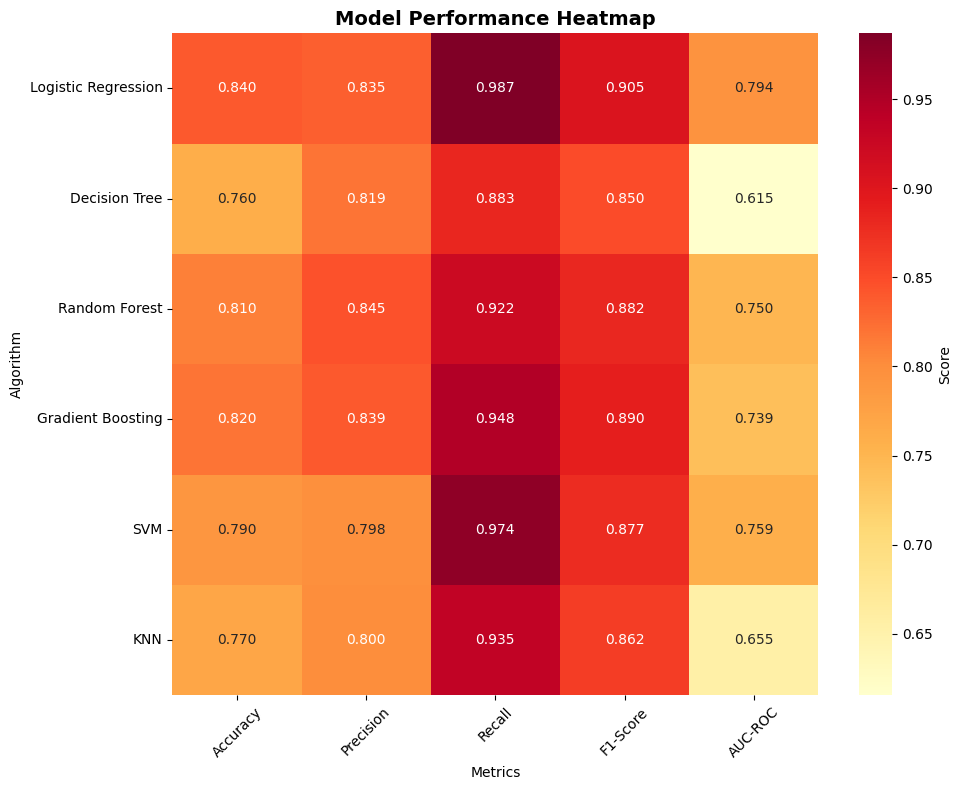


BEST MODEL: Logistic Regression
Best Model Performance:
  Accuracy: 0.8400
  Precision: 0.8352
  Recall: 0.9870
  F1-Score: 0.9048
  AUC-ROC: 0.7939
  CV Mean: 0.7900
  CV Std: 0.0443

HYPERPARAMETER TUNING FOR Logistic Regression

CLASSIFICATION REPORT FOR BEST MODEL
              precision    recall  f1-score   support

      Failed       0.89      0.35      0.50        23
      Passed       0.84      0.99      0.90        77

    accuracy                           0.84       100
   macro avg       0.86      0.67      0.70       100
weighted avg       0.85      0.84      0.81       100



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve)
import warnings
warnings.filterwarnings('ignore')

# Create the dataset
data = {
    'iq': [113.78966139442878, 94.62961011507367],
    'final_score': [0.6, 0.7],
    'attempts': [1, 1],
    'passed': [1, 1]  # 1 = passed, 0 = failed
}

df = pd.DataFrame(data)
print("Dataset shape:", df.shape)
print("\nFirst few rows:")
print(df)
print("\nDataset info:")
print(df.info())
print("\nClass distribution:")
print(df['passed'].value_counts())

# Since we only have 2 samples, let's generate synthetic data for demonstration
# In real scenarios, you would use your actual dataset
np.random.seed(42)
n_samples = 500

# Generate synthetic data based on the patterns
iq_mean, iq_std = 100, 15
final_score_mean, final_score_std = 0.65, 0.15

iq_data = np.random.normal(iq_mean, iq_std, n_samples)
final_score_data = np.random.normal(final_score_mean, final_score_std, n_samples)
attempts_data = np.random.choice([1, 2, 3], n_samples, p=[0.7, 0.2, 0.1])

# Create passed label based on rules
passed = []
for i in range(n_samples):
    score = (iq_data[i] / 100) * 0.3 + final_score_data[i] * 0.5 + (1/attempts_data[i]) * 0.2
    prob_passed = 1 / (1 + np.exp(-(score - 0.65) * 10))
    passed.append(1 if np.random.random() < prob_passed else 0)

# Create synthetic dataset
df_synthetic = pd.DataFrame({
    'iq': iq_data,
    'final_score': final_score_data,
    'attempts': attempts_data,
    'passed': passed
})

print("\n" + "="*60)
print("WORKING WITH SYNTHETIC DATASET (500 samples)")
print("="*60)
print("\nSynthetic dataset info:")
print(df_synthetic.head())
print(f"\nClass distribution:\n{df_synthetic['passed'].value_counts()}")

# Prepare features and target
X = df_synthetic[['iq', 'final_score', 'attempts']]
y = df_synthetic['passed']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Define classification algorithms
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier()
}

# Train and evaluate models
results = {}
predictions = {}
probabilities = {}

print("\n" + "="*60)
print("MODEL EVALUATION RESULTS")
print("="*60)

for name, clf in classifiers.items():
    # Train
    clf.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = clf.predict(X_test_scaled)
    y_pred_proba = clf.predict_proba(X_test_scaled)[:, 1] if hasattr(clf, "predict_proba") else None
    
    # Store predictions and probabilities
    predictions[name] = y_pred
    if y_pred_proba is not None:
        probabilities[name] = y_pred_proba
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None
    
    # Cross-validation
    cv_scores = cross_val_score(clf, X_train_scaled, y_train, cv=5)
    
    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'AUC-ROC': auc,
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    }
    
    print(f"\n{name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    if auc:
        print(f"  AUC-ROC:   {auc:.4f}")
    print(f"  CV Score:  {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

# Create results dataframe
results_df = pd.DataFrame(results).T
print("\n" + "="*60)
print("SUMMARY TABLE")
print("="*60)
print(results_df.round(4))

# Visualization 1: Model Comparison Bar Plot
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC', 'CV Mean']
for idx, metric in enumerate(metrics):
    if metric in results_df.columns:
        results_df[metric].sort_values(ascending=False).plot(kind='bar', ax=axes[idx])
        axes[idx].set_title(f'{metric} Comparison', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel(metric)
        axes[idx].set_xlabel('Algorithm')
        axes[idx].tick_params(axis='x', rotation=45)
        axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Visualization 2: Confusion Matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Failed', 'Passed'],
                yticklabels=['Failed', 'Passed'])
    axes[idx].set_title(f'{name}\nConfusion Matrix', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# Visualization 3: ROC Curves
plt.figure(figsize=(10, 8))

for name, y_pred_proba in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves - Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()

# Visualization 4: Feature Importance (for tree-based models)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
feature_names = ['IQ', 'Final Score', 'Attempts']

tree_models = ['Random Forest', 'Gradient Boosting', 'Decision Tree']
for idx, model_name in enumerate(tree_models):
    if model_name in classifiers:
        model = classifiers[model_name]
        model.fit(X_train_scaled, y_train)
        
        if hasattr(model, 'feature_importances_'):
            importances = model.feature_importances_
            axes[idx].barh(feature_names, importances)
            axes[idx].set_title(f'{model_name}\nFeature Importance', fontsize=12, fontweight='bold')
            axes[idx].set_xlabel('Importance')
            for i, v in enumerate(importances):
                axes[idx].text(v + 0.01, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.show()

# Visualization 5: Decision Boundary (IQ vs Final Score)
plt.figure(figsize=(12, 5))

# Best model based on accuracy
best_model_name = results_df['Accuracy'].idxmax()
best_model = classifiers[best_model_name]
best_model.fit(X_train_scaled, y_train)

# Create mesh grid
x_min, x_max = X_train_scaled[:, 0].min() - 1, X_train_scaled[:, 0].max() + 1
y_min, y_max = X_train_scaled[:, 1].min() - 1, X_train_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Predict on mesh grid
Z = best_model.predict(np.c_[xx.ravel(), yy.ravel(), np.zeros(xx.ravel().shape[0])])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdYlBu')
scatter = plt.scatter(X_train_scaled[:, 0], X_train_scaled[:, 1], 
                     c=y_train, cmap='RdYlBu', edgecolors='black', alpha=0.7)
plt.xlabel('IQ (scaled)', fontsize=12)
plt.ylabel('Final Score (scaled)', fontsize=12)
plt.title(f'{best_model_name} - Decision Boundary\n(Training Data)', fontsize=12, fontweight='bold')
plt.colorbar(scatter)

# Test data predictions
plt.subplot(1, 2, 2)
y_pred_test = best_model.predict(X_test_scaled)
correct = y_pred_test == y_test
plt.scatter(X_test_scaled[correct, 0], X_test_scaled[correct, 1], 
           c=y_test[correct], cmap='RdYlBu', marker='o', 
           edgecolors='green', linewidth=2, label='Correct', alpha=0.7)
plt.scatter(X_test_scaled[~correct, 0], X_test_scaled[~correct, 1], 
           c=y_test[~correct], cmap='RdYlBu', marker='x', 
           s=100, edgecolors='red', linewidth=2, label='Incorrect', alpha=0.7)
plt.xlabel('IQ (scaled)', fontsize=12)
plt.ylabel('Final Score (scaled)', fontsize=12)
plt.title(f'{best_model_name} - Test Set Predictions\n(Green edge = correct, Red X = incorrect)', 
          fontsize=10, fontweight='bold')
plt.legend()
plt.colorbar(scatter)

plt.tight_layout()
plt.show()

# Visualization 6: Performance Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(results_df[['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']], 
            annot=True, fmt='.3f', cmap='YlOrRd', cbar_kws={'label': 'Score'})
plt.title('Model Performance Heatmap', fontsize=14, fontweight='bold')
plt.ylabel('Algorithm')
plt.xlabel('Metrics')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Best Model Analysis
print("\n" + "="*60)
print(f"BEST MODEL: {best_model_name}")
print("="*60)
print(f"Best Model Performance:")
for metric, value in results_df.loc[best_model_name].items():
    if not pd.isna(value):
        print(f"  {metric}: {value:.4f}")

# Hyperparameter tuning for the best model
print("\n" + "="*60)
print(f"HYPERPARAMETER TUNING FOR {best_model_name}")
print("="*60)

if best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5, 10]
    }
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    }
elif best_model_name == 'SVM':
    param_grid = {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'kernel': ['rbf', 'linear']
    }
else:
    param_grid = {}
    
if param_grid:
    grid_search = GridSearchCV(best_model, param_grid, cv=5, scoring='accuracy')
    grid_search.fit(X_train_scaled, y_train)
    print(f"Best parameters: {grid_search.best_params_}")
    print(f"Best cross-validation score: {grid_search.best_score_:.4f}")
    
    # Evaluate tuned model
    tuned_model = grid_search.best_estimator_
    y_pred_tuned = tuned_model.predict(X_test_scaled)
    tuned_accuracy = accuracy_score(y_test, y_pred_tuned)
    print(f"Test accuracy after tuning: {tuned_accuracy:.4f}")
    
    if tuned_accuracy > results_df.loc[best_model_name, 'Accuracy']:
        print(f"✅ Improvement! Accuracy increased from {results_df.loc[best_model_name, 'Accuracy']:.4f} to {tuned_accuracy:.4f}")
    else:
        print(f"⚠️ No improvement. Consider different hyperparameters.")

print("\n" + "="*60)
print("CLASSIFICATION REPORT FOR BEST MODEL")
print("="*60)
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_best, target_names=['Failed', 'Passed']))